# 64/160/32 velocity and diagnosis analysis

This notebook compares the previous 64/128/64 model with the new modular 64/160/32 experiment. It covers diagnosis prediction, latent component speeds, decoder-induced shape speed, finite-difference/Jacobian agreement, residual shape energy, and direct/composed consistency.

The new test forecast uses one disease probability predicted from the baseline-fitted anchor. The true test diagnosis is used only for evaluation.

In [1]:
import importlib
import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

ROOT = Path('/home/jakaria/INR/Deep3DComp')
sys.path.insert(0, str(ROOT))
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

OLD_EXP = ROOT / 'examples/Torus_subset_100_id_age_progression/longitudinal_age_disease_conditioned_cocycle_shape_pair_loss_multiple_pairs_disentangled_velocity_64_128_64_binary_margin_adv'
NEW_EXP = ROOT / 'examples/Torus_subset_100_id_age_progression/velocity_64_160_32_pred_dx'
OLD_CHECKPOINT = '500'
NEW_CHECKPOINT = 'latest'
AGE_START = 0.5
AGE_STEP = 0.01
NUM_NEAR_SURFACE = 2048
RANDOM_CANDIDATES = 100000
torch.manual_seed(7)
np.random.seed(7)
print('device:', DEVICE)

device: cuda


## Load models and checkpoint-specific mean anchors

If the new checkpoint does not exist yet, the cell still reports the intended configuration and the later comparison cells skip the new model.

In [2]:
def strip_module_prefix(state):
    return {k[7:] if k.startswith('module.') else k: v for k, v in state.items()}

def load_latent_mean(exp_dir, checkpoint):
    path = exp_dir / 'LatentCodes' / f'{checkpoint}.pth'
    data = torch.load(path, map_location='cpu')
    codes = data['latent_codes']
    if isinstance(codes, dict):
        codes = codes['weight']
    if codes.ndim == 3:
        codes = codes[:, 0, :]
    return codes.float().mean(dim=0, keepdim=True).to(DEVICE), codes.float()

def load_experiment(exp_dir, checkpoint, flow_module_name):
    spec = json.loads((exp_dir / 'specs.json').read_text())
    model_path = exp_dir / 'ModelParameters' / f'{checkpoint}.pth'
    latent_path = exp_dir / 'LatentCodes' / f'{checkpoint}.pth'
    if not model_path.exists() or not latent_path.exists():
        print(f'checkpoint unavailable: {model_path}')
        return {'spec': spec, 'available': False, 'exp_dir': exp_dir}
    decoder_module = importlib.import_module('networks.' + spec['NetworkArch'])
    decoder = decoder_module.Decoder(spec['CodeLength'], **spec['NetworkSpecs']).to(DEVICE)
    flow_module = importlib.import_module(flow_module_name)
    flow = flow_module.build_temporal_flow(
        spec, spec['CodeLength'], spec['FlowHiddenDims'],
        age_condition_dim=spec.get('AgeConditionDim', 0),
    ).to(DEVICE)
    data = torch.load(model_path, map_location='cpu')
    decoder.load_state_dict(strip_module_prefix(data['model_state_dict']))
    flow.load_state_dict(strip_module_prefix(data['flow_state_dict']))
    decoder.eval(); flow.eval()
    mean_z, all_z = load_latent_mean(exp_dir, checkpoint)
    return {
        'spec': spec, 'decoder': decoder, 'flow': flow,
        'mean_z': mean_z, 'all_z': all_z, 'available': True,
        'epoch': data.get('epoch'), 'exp_dir': exp_dir,
    }

old_model = load_experiment(
    OLD_EXP, OLD_CHECKPOINT,
    'networks.longitudinal_disentangled_flow_64_128_64_adv',
)
new_model = load_experiment(
    NEW_EXP, NEW_CHECKPOINT,
    'networks.longitudinal_flow_64_160_32_pred_dx',
)
models = {'old_64_128_64': old_model, 'new_64_160_32': new_model}
for name, model in models.items():
    spec = model['spec']
    print(name, 'available=', model['available'], 'blocks=', (
        spec.get('VelocityAgeDim'), spec.get('VelocityDiseaseDim'),
        spec.get('VelocityResidualDim')))

old_64_128_64 available= True blocks= (64, 128, 64)
new_64_160_32 available= True blocks= (64, 160, 32)


## Diagnosis prediction

The trainer writes `train_epoch_*.csv` from all-visit training anchors and `test_epoch_*.csv` from baseline-only test anchors. Their difference directly exposes the anchor-inference mismatch.

all-visit train anchor train_epoch_2000.csv {'accuracy': 1.0, 'balanced_accuracy': 1.0, 'auc': 1.0, 'sensitivity': 1.0, 'specificity': 1.0}
baseline-only test anchor test_epoch_2000.csv {'accuracy': 0.9333333333333333, 'balanced_accuracy': 0.9444444444444444, 'auc': 0.8888888888888888, 'sensitivity': 0.8888888888888888, 'specificity': 1.0}


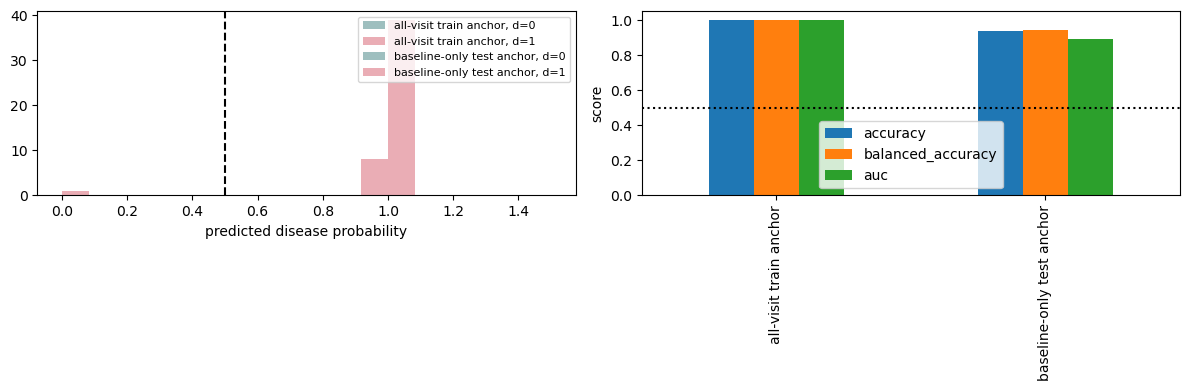

,accuracy,balanced_accuracy,auc,sensitivity,specificity
all-visit train anchor,1.000000,1.000000,1.000000,1.000000,1.0
baseline-only test anchor,0.933333,0.944444,0.888889,0.888889,1.0


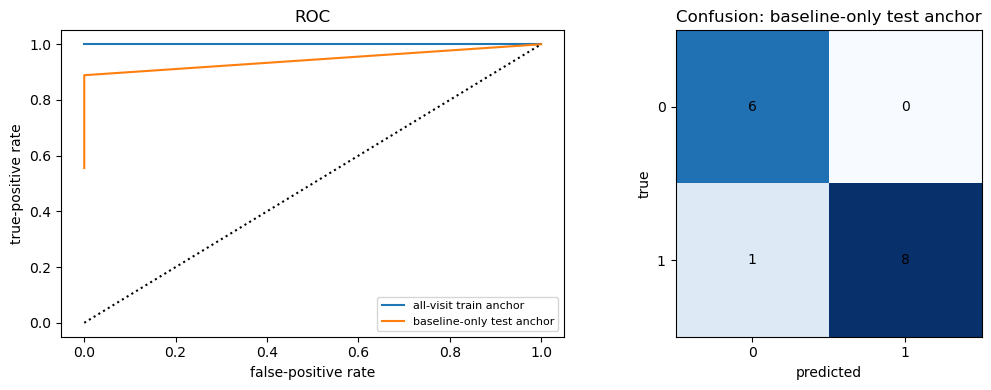

In [3]:
def latest_csv(folder, pattern):
    files = list(folder.glob(pattern))
    if not files:
        return None
    return max(files, key=lambda p: int(p.stem.rsplit('_', 1)[-1]))

def binary_metrics(frame):
    y = frame.true_diagnosis.to_numpy().astype(int)
    p = frame.predicted_probability.to_numpy().astype(float)
    pred = (p >= 0.5).astype(int)
    tp = np.sum((pred == 1) & (y == 1)); tn = np.sum((pred == 0) & (y == 0))
    fp = np.sum((pred == 1) & (y == 0)); fn = np.sum((pred == 0) & (y == 1))
    sens = tp / max(1, tp + fn); spec = tn / max(1, tn + fp)
    pos = p[y == 1]; neg = p[y == 0]
    auc = np.nan if not len(pos) or not len(neg) else np.mean(pos[:, None] > neg[None, :]) + 0.5 * np.mean(pos[:, None] == neg[None, :])
    return {'accuracy': np.mean(pred == y), 'balanced_accuracy': 0.5*(sens+spec), 'auc': auc, 'sensitivity': sens, 'specificity': spec}

pred_dir = NEW_EXP / 'DiagnosisPredictions'
train_csv = latest_csv(pred_dir, 'train_epoch_*.csv')
test_csv = latest_csv(pred_dir, 'test_epoch_*.csv')
diagnosis_frames = {}
for split_name, path in [('all-visit train anchor', train_csv), ('baseline-only test anchor', test_csv)]:
    if path is not None:
        frame = pd.read_csv(path)
        diagnosis_frames[split_name] = frame
        print(split_name, path.name, binary_metrics(frame))
    else:
        print(split_name, 'CSV not available yet')

if diagnosis_frames:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for split_name, frame in diagnosis_frames.items():
        for diagnosis, color in [(0, '#287271'), (1, '#d1495b')]:
            vals = frame.loc[frame.true_diagnosis == diagnosis, 'predicted_probability']
            axes[0].hist(vals, bins=12, alpha=.45, label=f'{split_name}, d={diagnosis}', color=color)
    axes[0].axvline(.5, color='black', ls='--'); axes[0].set_xlabel('predicted disease probability')
    axes[0].legend(fontsize=8)
    metric_table = pd.DataFrame({k: binary_metrics(v) for k, v in diagnosis_frames.items()}).T
    metric_table[['accuracy', 'balanced_accuracy', 'auc']].plot.bar(ax=axes[1], ylim=(0, 1.05))
    axes[1].axhline(.5, color='black', ls=':'); axes[1].set_ylabel('score')
    plt.tight_layout(); plt.show()
    display(metric_table)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for split_name, frame in diagnosis_frames.items():
        y = frame.true_diagnosis.to_numpy().astype(int); p = frame.predicted_probability.to_numpy()
        thresholds = np.linspace(1, 0, 201)
        tpr = [np.mean(p[y == 1] >= threshold) if np.any(y == 1) else np.nan for threshold in thresholds]
        fpr = [np.mean(p[y == 0] >= threshold) if np.any(y == 0) else np.nan for threshold in thresholds]
        axes[0].plot(fpr, tpr, label=split_name)
    axes[0].plot([0,1],[0,1], color='black', ls=':'); axes[0].set(xlabel='false-positive rate', ylabel='true-positive rate', title='ROC'); axes[0].legend(fontsize=8)
    test_name = 'baseline-only test anchor' if 'baseline-only test anchor' in diagnosis_frames else list(diagnosis_frames)[-1]
    test_frame = diagnosis_frames[test_name]; y = test_frame.true_diagnosis.to_numpy().astype(int); pred = (test_frame.predicted_probability.to_numpy() >= .5).astype(int)
    matrix = np.array([[np.sum((y==0)&(pred==0)), np.sum((y==0)&(pred==1))], [np.sum((y==1)&(pred==0)), np.sum((y==1)&(pred==1))]])
    axes[1].imshow(matrix, cmap='Blues'); axes[1].set(title=f'Confusion: {test_name}', xlabel='predicted', ylabel='true', xticks=[0,1], yticks=[0,1])
    for row in range(2):
        for column in range(2): axes[1].text(column, row, int(matrix[row,column]), ha='center', va='center')
    plt.tight_layout(); plt.show()

## Diagnosis learning curves

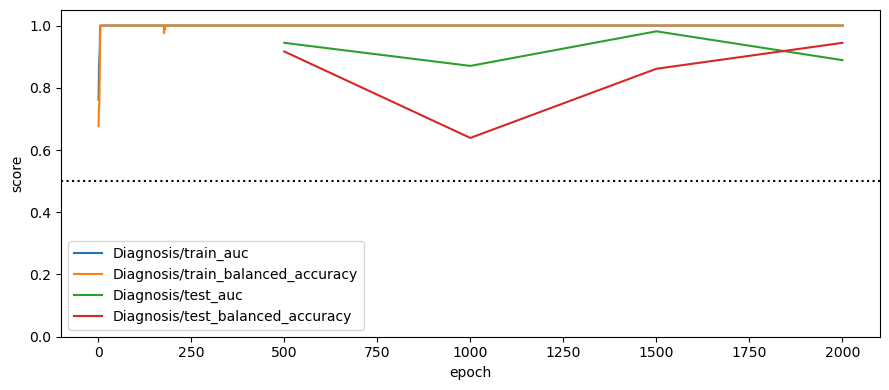

In [4]:
try:
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
    event_files = sorted((NEW_EXP / 'TensorBoard').glob('events.out.tfevents.*'))
    if event_files:
        accumulator = EventAccumulator(str(event_files[0]), size_guidance={'scalars': 0})
        accumulator.Reload()
        scalar_tags = set(accumulator.Tags().get('scalars', []))
        curve_tags = ['Diagnosis/train_auc', 'Diagnosis/train_balanced_accuracy', 'Diagnosis/test_auc', 'Diagnosis/test_balanced_accuracy']
        plt.figure(figsize=(9, 4))
        for tag in curve_tags:
            if tag in scalar_tags:
                events = accumulator.Scalars(tag)
                plt.plot([e.step for e in events], [e.value for e in events], label=tag)
        plt.ylim(0, 1.05); plt.axhline(.5, color='black', ls=':'); plt.xlabel('epoch'); plt.ylabel('score'); plt.legend(); plt.tight_layout(); plt.show()
    else:
        print('TensorBoard events are not available yet')
except ImportError:
    print('tensorboard package is unavailable in this kernel')

## Latent component speeds

These are interval-average latent velocities over `[t, t+h]`. The new model uses its anchor-predicted soft disease gate. The old model is shown with explicit healthy and diseased gates.

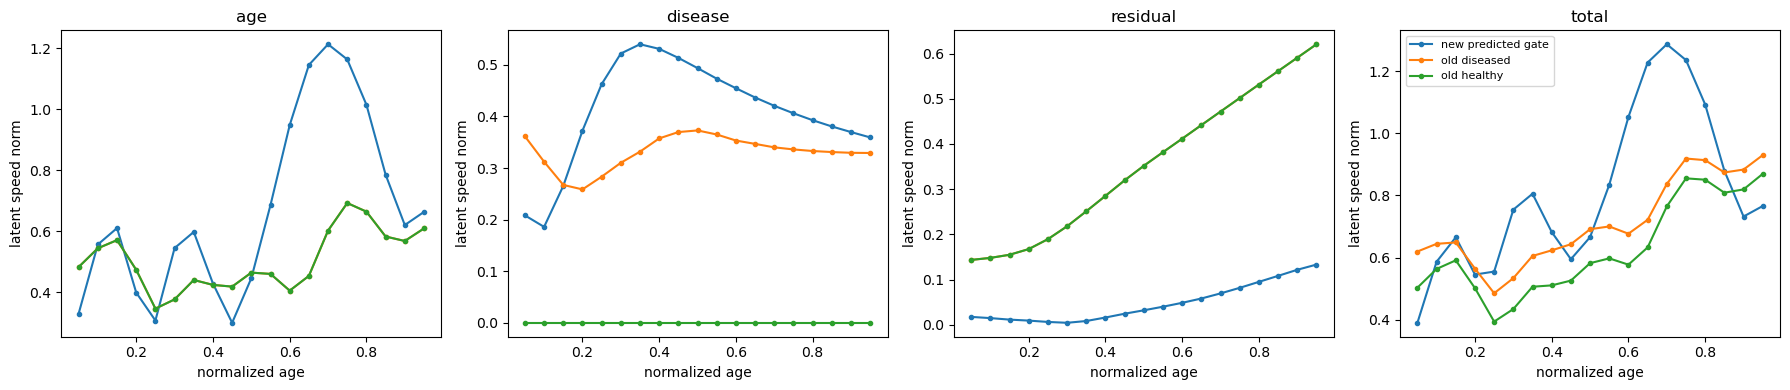

,model,age,gate,age_speed,disease_speed,residual_speed,total_speed
0,old healthy,0.05,0.0,0.482351,0.0,0.143362,0.503205
1,old healthy,0.10,0.0,0.543802,0.0,0.147890,0.563553
2,old healthy,0.15,0.0,0.570548,0.0,0.154783,0.591171
3,old healthy,0.20,0.0,0.473062,0.0,0.167359,0.501793
4,old healthy,0.25,0.0,0.345729,0.0,0.189320,0.394171


In [5]:
def predicted_gate(model, z):
    flow = model['flow']
    if hasattr(flow, 'anchor_disease_probability'):
        with torch.no_grad():
            return flow.anchor_disease_probability(z).reshape(1, 1)
    return z.new_ones((1, 1))

def component_rows(name, model, gate=None, age_grid=np.linspace(0.05, 0.95, 19), h=0.01):
    if not model['available']:
        return []
    z = model['mean_z']
    if gate is None:
        gate = predicted_gate(model, z)
    rows = []
    with torch.no_grad():
        for age in age_grid:
            s = z.new_tensor([[age]]); t = z.new_tensor([[age+h]])
            comp = model['flow'].velocity_components(z, s, t, age_cond=gate)
            rows.append({
                'model': name, 'age': age, 'gate': float(gate.item()),
                'age_speed': float(comp['age'].norm().item()),
                'disease_speed': float(comp['disease'].norm().item()),
                'residual_speed': float(comp['residual'].norm().item()),
                'total_speed': float(comp['velocity'].norm().item()),
            })
    return rows

speed_rows = []
speed_rows += component_rows('old healthy', old_model, old_model.get('mean_z', torch.zeros(1,256,device=DEVICE)).new_zeros((1,1)))
speed_rows += component_rows('old diseased', old_model, old_model.get('mean_z', torch.zeros(1,256,device=DEVICE)).new_ones((1,1)))
speed_rows += component_rows('new predicted gate', new_model)
speed_df = pd.DataFrame(speed_rows)
if not speed_df.empty:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=True)
    for ax, column, title in zip(axes, ['age_speed','disease_speed','residual_speed','total_speed'], ['age','disease','residual','total']):
        for model_name, frame in speed_df.groupby('model'):
            ax.plot(frame.age, frame[column], marker='o', ms=3, label=model_name)
        ax.set_title(title); ax.set_xlabel('normalized age'); ax.set_ylabel('latent speed norm')
    axes[-1].legend(fontsize=8); plt.tight_layout(); plt.show()
display(speed_df.head())

## Decoder-induced normal speed

For an INR `G(x,z)`, the local normal speed is

$$c_n(x)=-\frac{\nabla_zG(x,z)^T v}{\|\nabla_xG(x,z)\|+\epsilon}.$$

The finite-difference estimate uses `G(x,z)-G(x,z+h v)` divided by `h ||grad_x G||`. Agreement validates the Jacobian calculation and sign convention.

In [6]:
def decode(decoder, z, xyz, batch=32768):
    values = []
    with torch.no_grad():
        for start in range(0, len(xyz), batch):
            x = xyz[start:start+batch].to(DEVICE)
            values.append(decoder(torch.cat([z.expand(len(x), -1), x], dim=1)).cpu())
    return torch.cat(values).reshape(-1)

def near_surface_points(model, count=NUM_NEAR_SURFACE, candidates=RANDOM_CANDIDATES):
    xyz = torch.rand(candidates, 3) * 2.0 - 1.0
    sdf = decode(model['decoder'], model['mean_z'], xyz)
    keep = torch.topk(sdf.abs(), k=min(count, len(sdf)), largest=False).indices
    return xyz[keep].to(DEVICE)

def pad_component(component, kind, spec):
    a = int(spec['VelocityAgeDim']); d = int(spec['VelocityDiseaseDim']); r = int(spec['VelocityResidualDim'])
    out = component.new_zeros((component.shape[0], a+d+r))
    if kind == 'age': out[:, :a] = component
    elif kind == 'disease': out[:, a:a+d] = component
    elif kind == 'residual': out[:, a+d:] = component
    elif kind == 'total': out = component
    return out

def normal_speed(model, xyz, kind, gate, age=AGE_START, h=AGE_STEP):
    z = model['mean_z'].detach()
    s = z.new_tensor([[age]]); t = z.new_tensor([[age+h]])
    with torch.no_grad():
        comp = model['flow'].velocity_components(z, s, t, age_cond=gate)
        key = 'velocity' if kind == 'total' else kind
        v = pad_component(comp[key], kind, model['spec'])
    x = xyz.detach().clone().requires_grad_(True)
    zz = z.expand(len(x), -1).detach().clone().requires_grad_(True)
    sdf = model['decoder'](torch.cat([zz, x], dim=1)).reshape(-1)
    grad_z, grad_x = torch.autograd.grad(sdf.sum(), (zz, x), create_graph=False)
    denom = grad_x.norm(dim=1).clamp_min(1e-8)
    jac = -(grad_z * v.expand(len(x), -1)).sum(dim=1) / denom
    with torch.no_grad():
        sdf_next = model['decoder'](torch.cat([zz.detach() + h*v.expand(len(x), -1), x.detach()], dim=1)).reshape(-1)
        fd = (sdf.detach() - sdf_next) / (h * denom.detach())
    return jac.detach().cpu().numpy(), fd.detach().cpu().numpy()

shape_speed_rows = []
for model_name, model in models.items():
    if not model['available']:
        continue
    xyz = near_surface_points(model)
    gate = predicted_gate(model, model['mean_z']) if model_name.startswith('new') else model['mean_z'].new_ones((1,1))
    for kind in ['age', 'disease', 'residual', 'total']:
        jac, fd = normal_speed(model, xyz, kind, gate)
        corr = np.corrcoef(jac, fd)[0,1] if np.std(jac) > 0 and np.std(fd) > 0 else np.nan
        rel = np.mean(np.abs(jac-fd)) / max(1e-8, np.mean(np.abs(fd)))
        shape_speed_rows.append({'model':model_name, 'component':kind, 'rms_jacobian':np.sqrt(np.mean(jac**2)), 'rms_finite_difference':np.sqrt(np.mean(fd**2)), 'correlation':corr, 'relative_error':rel})
shape_speed_df = pd.DataFrame(shape_speed_rows)
display(shape_speed_df)

,model,component,rms_jacobian,rms_finite_difference,correlation,relative_error
0,old_64_128_64,age,0.006586,0.006593,0.999551,0.014643
1,old_64_128_64,disease,0.023783,0.023812,0.999304,0.007867
2,old_64_128_64,residual,0.063104,0.063159,0.992885,0.008524
3,old_64_128_64,total,0.086196,0.086328,0.993737,0.011351
4,new_64_160_32,age,0.033576,0.033131,0.959001,0.019654
5,new_64_160_32,disease,0.024957,0.024884,0.997010,0.013503
6,new_64_160_32,residual,0.007258,0.007258,0.999548,0.001110
7,new_64_160_32,total,0.064353,0.063570,0.972780,0.020992


## Signed shape-speed maps

These 3D near-surface maps use one shared symmetric color range per model. Negative and positive values indicate opposite normal directions under the Jacobian sign convention.

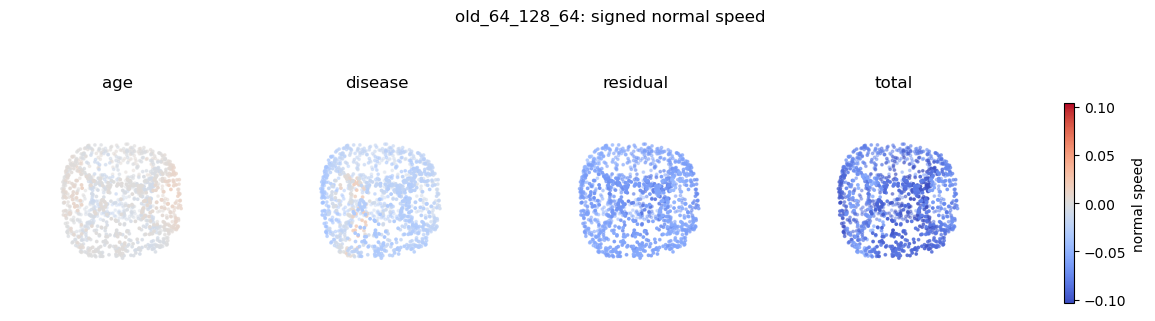

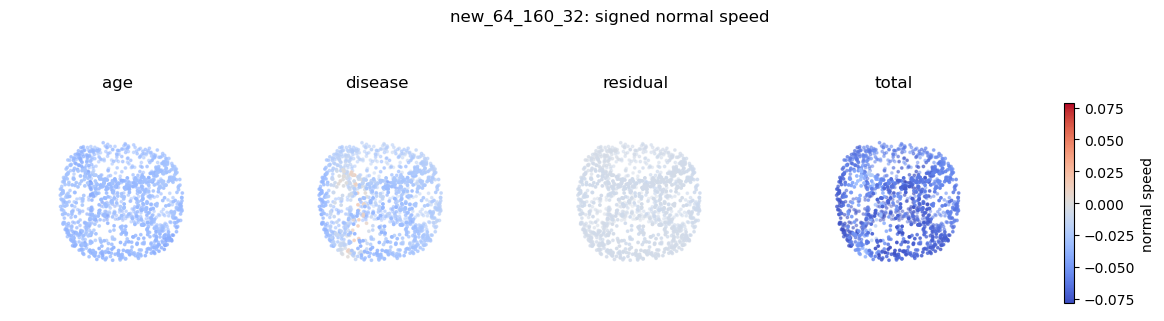

In [7]:
for model_name, model in models.items():
    if not model['available']:
        continue
    xyz = near_surface_points(model, count=1200, candidates=60000)
    gate = predicted_gate(model, model['mean_z']) if model_name.startswith('new') else model['mean_z'].new_ones((1,1))
    maps = {}
    for kind in ['age', 'disease', 'residual', 'total']:
        maps[kind] = normal_speed(model, xyz, kind, gate)[0]
    vmax = np.quantile(np.abs(np.concatenate(list(maps.values()))), 0.98)
    points = xyz.detach().cpu().numpy()
    fig = plt.figure(figsize=(16, 4))
    for index, kind in enumerate(['age', 'disease', 'residual', 'total'], start=1):
        ax = fig.add_subplot(1, 4, index, projection='3d')
        scatter = ax.scatter(points[:,0], points[:,1], points[:,2], c=maps[kind], s=3, cmap='coolwarm', vmin=-vmax, vmax=vmax)
        ax.set_title(kind); ax.set_axis_off(); ax.view_init(elev=25, azim=45)
    fig.suptitle(f'{model_name}: signed normal speed')
    fig.colorbar(scatter, ax=fig.axes, shrink=.65, label='normal speed')
    plt.show()

## Residual shape-energy fraction and component separation

The residual fraction is computed from RMS normal speed, not latent norm. This detects whether the decoder amplifies the smaller 32D residual block.

component,age,disease,residual,total,residual_fraction
model,,,,,
new_64_160_32,0.001127,0.000623,0.000053,0.004141,0.029222
old_64_128_64,0.000043,0.000566,0.003982,0.007430,0.867353


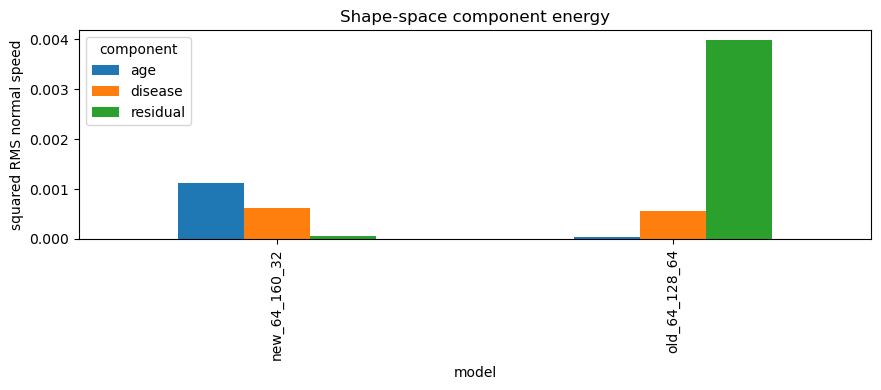

In [8]:
if not shape_speed_df.empty:
    energy = shape_speed_df.pivot(index='model', columns='component', values='rms_jacobian') ** 2
    energy['residual_fraction'] = energy['residual'] / (energy['age'] + energy['disease'] + energy['residual'] + 1e-12)
    display(energy)
    energy[['age','disease','residual']].plot.bar(figsize=(9,4), title='Shape-space component energy')
    plt.ylabel('squared RMS normal speed'); plt.tight_layout(); plt.show()

## Direct versus composed latent transition

This uses the same fixed gate for direct and composed paths. Lower discrepancy means the learned transition better respects the cocycle constraint.

In [9]:
def transition(flow, z, s, t, gate):
    ss = z.new_tensor([[s]]); tt = z.new_tensor([[t]])
    return z + (tt-ss) * flow(z, ss, tt, age_cond=gate)

rows = []
for model_name, model in models.items():
    if not model['available']:
        continue
    z = model['mean_z']
    gate = predicted_gate(model, z) if model_name.startswith('new') else z.new_ones((1,1))
    with torch.no_grad():
        for s, r, t in [(0.1,0.3,0.8),(0.2,0.5,0.9),(0.05,0.15,0.4)]:
            direct = transition(model['flow'], z, s, t, gate)
            composed = transition(model['flow'], transition(model['flow'], z, s, r, gate), r, t, gate)
            rows.append({'model':model_name,'s':s,'r':r,'t':t,'latent_rmse':float(torch.mean((direct-composed)**2).sqrt().item()),'relative_error':float((direct-composed).norm().item() / max(1e-8,(direct-z).norm().item()))})
display(pd.DataFrame(rows))

,model,s,r,t,latent_rmse,relative_error
0,old_64_128_64,0.10,0.30,0.8,0.001783,0.062681
1,old_64_128_64,0.20,0.50,0.9,0.002117,0.064292
2,old_64_128_64,0.05,0.15,0.4,0.000570,0.068156
3,new_64_160_32,0.10,0.30,0.8,0.001577,0.041549
4,new_64_160_32,0.20,0.50,0.9,0.002381,0.058542
5,new_64_160_32,0.05,0.15,0.4,0.000864,0.084279


## Interpretation checklist

- Compare all-visit training-anchor AUC with baseline-only test-anchor AUC. A large drop indicates anchor-inference mismatch.
- Compare predicted-soft test Chamfer from TensorBoard with the previous epoch-500 result and with an oracle-mode rerun.
- Require low Jacobian/finite-difference error before interpreting component speed maps.
- The 32D residual is successful only if its shape-energy fraction decreases; a smaller latent norm alone is insufficient.
- Inspect whether disease speed remains separated while residual diagnosis leakage and residual shape energy decrease.